# Asymmetry in U.S. Unemployment Dynamics

**Research question:** Does unemployment increase faster during recessions than it decreases during economic recoveries?

**H0 (null):** The magnitude of the average monthly change in the unemployment rate is the same during contractions and during recoveries.

**H1 (alternative):** The monthly increase during contractions exceeds in magnitude the monthly decrease during recoveries — unemployment rises like a rocket and falls like a feather.

All hypotheses, series, regime definitions and robustness checks were fixed in advance in
`Plan.md` before any data were pulled. The tests below are therefore **one-sided**: H1 is
directional, predicting that ascents are *faster*, not merely *different*. Nothing in this
notebook was chosen after seeing the results.

Data: FRED, Federal Reserve Bank of St. Louis.

**Notebook map**

| Section | Contents |
|---|---|
| 0 | Setup and API credentials |
| 1 | Data pull from FRED |
| 2 | Data cleaning |
| 3 | Merge `UNRATE` and `USREC` |
| 4 | Calculate unemployment changes (monthly and per business cycle) |
| 5 | Group comparison (recession vs recovery) |
| 6 | Regression test |
| 7 | Charts |
| 8 | Conclusion |

---

## 0. Setup

Imports, plotting defaults, output folders, and the helpers used throughout.

`fmt_table` prints DataFrames at four **significant** digits rather than four decimal
places, because several p-values here are of order 1e-20 and a fixed decimal format would
render every one of them as `0.000`. `fmt_p` goes further: a few p-values fall below
~1e-308 and are stored as exactly `0.0` by double-precision arithmetic, so they are
reported as a bound rather than as a literal zero, which would claim infinite precision.

`outside_covid` defines the 2020–21 exclusion window once, so every COVID robustness
check in Sections 5 and 6 drops exactly the same months. `add_source` prints the data
source beneath each chart, naming the FRED series drawn in it.

Everything the notebook writes goes to `data/` (API pulls and the episode table) or
`results/` (figures and tables).

In [ ]:
%matplotlib inline

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from dotenv import load_dotenv
from fredapi import Fred

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 150)

plt.rcParams.update({
    "figure.figsize": (11, 5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def fmt_table(frame):
    """Render a DataFrame at 4 significant digits, so tiny p-values stay legible."""
    return frame.to_string(float_format=lambda v: f"{v:.4g}")


def fmt_p(p):
    """Format a p-value, distinguishing underflow from a literal zero."""
    if pd.isna(p):
        return "n/a"
    if p == 0:
        return "<1e-308 (underflow)"
    return f"{p:.4g}"


COVID_START, COVID_END = "2020-01-01", "2021-12-01"


def outside_covid(index):
    """True for months outside the 2020-21 COVID window."""
    return (index < COVID_START) | (index > COVID_END)


SOURCE_AGENCY = {"UNRATE": "BLS", "USREC": "NBER", "PAYEMS": "BLS", "NROU": "CBO"}


def add_source(fig, *series_ids):
    """Print the data source beneath a figure, naming each FRED series drawn in it."""
    series = ", ".join(f"{s} ({SOURCE_AGENCY[s]})" for s in series_ids)
    fig.text(0.01, -0.01, f"Source: FRED, Federal Reserve Bank of St. Louis. Series: {series}.",
             ha="left", va="top", fontsize=8, color="0.35")


PROJECT_ROOT = Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"

for _d in (RAW_DIR, PROCESSED_DIR, FIGURES_DIR, TABLES_DIR):
    _d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\Sylvia Ahmed\OneDrive\Desktop\usf ms\ECON_630_1_TOM_ Python\calude ass\unemployment_recession_analysis


### 0.1 FRED API credentials

`load_dotenv()` reads the local `.env` file into the process environment; `os.getenv`
then retrieves the key. The key never appears in this notebook, and `.env` is listed in
`.gitignore` — a key committed to a public repository is a published key.

`.env` must contain one line:

```
FRED_API_KEY=your_key_here
```

The cell fails loudly rather than returning `None`, so a missing key is caught here
instead of surfacing as a confusing error inside the first API call.

In [ ]:
load_dotenv()

FRED_API_KEY = os.getenv("FRED_API_KEY")

if not FRED_API_KEY:
    raise RuntimeError(
        "FRED_API_KEY is not set. Create a .env file in the project root containing "
        "FRED_API_KEY=your_key_here, or set the variable in your shell. "
        "Free keys: https://fredaccount.stlouisfed.org/apikeys"
    )

fred = Fred(api_key=FRED_API_KEY)
print(f"FRED client ready (key loaded from environment, {len(FRED_API_KEY)} characters).")

FRED client ready (key loaded from environment, 32 characters).


---
## 1. Data Pull

Four series are pulled from FRED, each with a specific job:

| Series | Description | Role |
|---|---|---|
| `UNRATE` | Civilian unemployment rate, 16+, seasonally adjusted | Dependent variable |
| `USREC` | NBER-based recession indicator, 1 = contraction month | Defines the regimes |
| `PAYEMS` | Total nonfarm payroll employment | Robustness: immune to labour-force exit |
| `NROU` | CBO noncyclical rate of unemployment (quarterly) | Robustness: the natural rate is not constant over 1948–2026 |

**Every run pulls from the API.** With `REFRESH = True` (the default) each series is
downloaded from FRED through `fredapi` and saved to `data/raw/<SERIES>.csv`. Setting
`REFRESH = False` reuses those saved pulls, which is useful offline; they are still the
output of an earlier API call, never a manually downloaded file.

**Data vintage.** `UNRATE` is *revised*: the BLS re-estimates seasonal factors every
January, so a rerun months from now can return slightly different numbers. Every pull is
therefore stamped in `data/raw/_manifest.csv` with its retrieval time, its source (`FRED`
or a saved pull) and its last observation, so the vintage behind any result is documented.

The API call is wrapped so that an invalid key or a bad series ID produces a readable
message rather than an opaque error from inside `fredapi`.

In [ ]:
REFRESH = True  # False reuses the saved pulls in data/raw/ instead of calling the API

SERIES = {
    "UNRATE": "Civilian unemployment rate, 16+, SA (%)",
    "USREC": "NBER recession indicator (1 = contraction)",
    "PAYEMS": "Total nonfarm payroll employment (thousands)",
    "NROU": "CBO noncyclical rate of unemployment (%, quarterly)",
}

MANIFEST = RAW_DIR / "_manifest.csv"


def _stamp(series_id, series, source):
    """Record what was pulled and when, so the data vintage behind a result is known."""
    row = pd.DataFrame([{
        "series_id": series_id,
        "source": source,
        "recorded_at": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"),
        "n_obs": len(series),
        "first_obs": f"{series.index.min():%Y-%m}",
        "last_obs": f"{series.index.max():%Y-%m}",
        "description": SERIES[series_id],
    }])
    if MANIFEST.exists():
        prior = pd.read_csv(MANIFEST)
        row = pd.concat([prior[prior["series_id"] != series_id], row], ignore_index=True)
    row.sort_values("series_id").to_csv(MANIFEST, index=False)


def fetch(series_id, refresh=REFRESH):
    """Return a FRED series, pulled from the API or, if refresh is False, from data/raw/."""
    path = RAW_DIR / f"{series_id}.csv"
    if path.exists() and not refresh:
        series = pd.read_csv(path, index_col="date", parse_dates=True)[series_id]
        source = "cache"
    else:
        try:
            series = fred.get_series(series_id)
        except Exception as exc:
            raise RuntimeError(
                f"FRED request for '{series_id}' failed. Check that FRED_API_KEY is a valid "
                f"32-character key and that the series ID exists on fred.stlouisfed.org. "
                f"Original error: {exc}"
            ) from exc
        series.index = pd.to_datetime(series.index)
        series = series.rename(series_id)
        series.index.name = "date"
        series.to_csv(path)
        source = "FRED"
    series = series.rename(series_id)
    _stamp(series_id, series, source)
    return series


raw = {series_id: fetch(series_id) for series_id in SERIES}
print("Data vintage manifest (data/raw/_manifest.csv):\n")
print(fmt_table(pd.read_csv(MANIFEST).set_index("series_id")))

Data vintage manifest (data/raw/_manifest.csv):

          source       recorded_at  n_obs first_obs last_obs                                          description
series_id                                                                                                        
NROU        FRED  2026-09-29 18:28    352   1949-01  2036-10  CBO noncyclical rate of unemployment (%, quarterly)
PAYEMS      FRED  2026-09-29 18:28   1052   1939-01  2026-08         Total nonfarm payroll employment (thousands)
UNRATE      FRED  2026-09-29 18:28    944   1948-01  2026-08              Civilian unemployment rate, 16+, SA (%)
USREC       FRED  2026-09-29 18:28   2061   1854-12  2026-08           NBER recession indicator (1 = contraction)


---
## 2. Data Cleaning

Three steps:

1. **Put everything on one monthly grid.** FRED stamps monthly observations on the first
   of the month, so `asfreq("MS")` produces a regular month-start index on which a
   genuine gap shows up as a `NaN` row rather than a silently skipped month. Because
   `asfreq` would quietly *drop* any observation not stamped on the 1st, the count of
   off-grid dates is checked first rather than assumed to be zero.
2. **Interpolate `NROU` to monthly.** It is quarterly. `limit_area="inside"` interpolates
   only between observed quarters and refuses to extrapolate beyond the series' span.
   The natural rate moves slowly, so linear interpolation within a quarter is innocuous —
   but it is interpolation, and the resulting monthly series is not data.
3. **Inspect, do not trim.** The series start at different dates (`USREC` 1854, `PAYEMS`
   1939, `UNRATE` 1948, `NROU` 1949), so leading `NaN`s are expected. Trimming happens in
   Section 3.

In [ ]:
# Data Cleaning and Preparation
df = pd.concat(raw.values(), axis=1, sort=True)
df.index.name = "date"

off_grid = int((df.index.day != 1).sum())
duplicate_dates = int(df.index.duplicated().sum())
print(f"Observations not stamped on the 1st of a month: {off_grid} (asfreq would drop these)")
print(f"Duplicate dates in the combined index: {duplicate_dates}")

df = df.asfreq("MS")
df["NROU"] = df["NROU"].interpolate(method="linear", limit_area="inside")

print(f"\nCombined frame: {df.shape[0]} months x {df.shape[1]} series")
print(f"Index runs {df.index.min():%Y-%m} to {df.index.max():%Y-%m}")
print(f"Index unique and sorted: {df.index.is_unique and df.index.is_monotonic_increasing}\n")

coverage = pd.DataFrame({
    "first_obs": df.apply(lambda s: s.first_valid_index()),
    "last_obs": df.apply(lambda s: s.last_valid_index()),
    "n_obs": df.notna().sum(),
    "n_missing": df.isna().sum(),
    "dtype": df.dtypes.astype(str),
})
coverage

Observations not stamped on the 1st of a month: 0 (asfreq would drop these)
Duplicate dates in the combined index: 0

Combined frame: 2183 months x 4 series
Index runs 1854-12 to 2036-10
Index unique and sorted: True



,first_obs,last_obs,n_obs,n_missing,dtype
UNRATE,1948-01-01,2026-08-01,943,1240,float64
USREC,1854-12-01,2026-08-01,2061,122,float64
PAYEMS,1939-01-01,2026-08-01,1052,1131,float64
NROU,1949-01-01,2036-10-01,1054,1129,float64


---
## 3. Merge `UNRATE` and `USREC`

The analysis sample is the overlap of the two key series: every month for which both an
unemployment rate and a recession flag exist. `USREC` reaches back to 1854, so the
binding constraint is `UNRATE`, which begins in January 1948.

**Missing months stay on the grid.** The sample is trimmed to the span where both series
exist, but rows are *not* dropped inside it. Dropping a missing month would make the next
month's difference span two months, and it would enter Section 4 as if it were a one-month
change. Kept as `NaN`, the missing month makes the month-over-month change `NaN` for itself
and the month after, and both simply drop out of every test. FRED has no `UNRATE`
observation for October 2025, when the federal government shutdown halted the household
survey; the cell lists every such month rather than assuming there are none.

`USREC` is cast from float to integer so the grouping and the regression dummy read cleanly.

**On the `USREC` dating convention.** Rather than assert a convention, the cell prints the
months around the December 2007 NBER peak so the alignment is visible: whether the flag
switches on in the peak month or the month after can be read directly off the output.
This matters only for labelling. **The analysis does not depend on it** — Section 4.2
locates every turning point on the unemployment series itself, precisely so that the
result is not hostage to a dating convention.

In [ ]:
span = df[["UNRATE", "USREC"]].dropna().index
df = df.loc[span.min():span.max()].copy()
df["USREC"] = df["USREC"].astype(int)

missing_months = df.index[df["UNRATE"].isna()]
missing_list = ", ".join(f"{m:%Y-%m}" for m in missing_months) or "none"

print(f"Analysis sample: {df.index.min():%Y-%m} to {df.index.max():%Y-%m}  ({len(df)} months)")
print(f"Months with no UNRATE observation: {missing_list}  (kept on the grid as NaN)")
print(f"Recession months: {df['USREC'].sum()}  ({df['USREC'].mean():.1%} of the sample)")
print(f"Unemployment rate ranges {df['UNRATE'].min():.1f}% to {df['UNRATE'].max():.1f}%")

print("\nUSREC alignment around the NBER peak of December 2007:")
print(fmt_table(df.loc["2007-10":"2008-03", ["UNRATE", "USREC"]]))

Analysis sample: 1948-01 to 2026-08  (944 months)
Months with no UNRATE observation: 2025-10  (kept on the grid as NaN)
Recession months: 124  (13.1% of the sample)
Unemployment rate ranges 2.5% to 14.8%

USREC alignment around the NBER peak of December 2007:
            UNRATE  USREC
date                     
2007-10-01     4.7      0
2007-11-01     4.7      0
2007-12-01       5      0
2008-01-01       5      1
2008-02-01     4.9      1
2008-03-01     5.1      1


---
## 4. Calculate Unemployment Changes

The question is about *speed*, so the object of interest is the change in the
unemployment rate, not its level. Changes are computed at two levels of aggregation:

- **4.1 Monthly changes** — the month-over-month difference, used for the pooled
  comparison and the regressions.
- **4.2 Cycle-level changes** — for each business cycle, the average speed of the rise
  and of the fall, in percentage points per month, plus the duration of each phase.
- **4.3** tags every month with its cycle phase; **4.4** validates the result.

### 4.1 Monthly changes

| Column | Definition | Why |
|---|---|---|
| `d_unrate` | Month-over-month change in `UNRATE`, pp | The main dependent variable |
| `d_unrate_lag1` | Its own first lag | Monthly changes may be serially correlated; the regression must control for momentum |
| `unrate_ma3` / `d_unrate_ma3` | Centred 3-month moving average and its change | The household survey is a sample; single-month moves contain sampling noise |
| `payems_growth` | Percent change in nonfarm payrolls | The unemployment rate falls when people find work **and** when they stop looking; payrolls are not subject to the second channel |
| `u_gap` / `d_u_gap` | `UNRATE` minus the CBO natural rate, and its change | Comparing raw levels across 1948–2026 implicitly assumes a constant u\*, which is false |

The last two columns exist to answer the two most obvious objections to the headline
result, and both are used in the robustness table in Section 5.4.

In [ ]:
df["d_unrate"] = df["UNRATE"].diff()
df["d_unrate_lag1"] = df["d_unrate"].shift(1)
df["unrate_ma3"] = df["UNRATE"].rolling(3, center=True).mean()
df["d_unrate_ma3"] = df["unrate_ma3"].diff()
df["payems_growth"] = df["PAYEMS"].pct_change() * 100
df["u_gap"] = df["UNRATE"] - df["NROU"]
df["d_u_gap"] = df["u_gap"].diff()

df[["UNRATE", "d_unrate", "unrate_ma3", "payems_growth", "u_gap"]].describe()

,UNRATE,d_unrate,unrate_ma3,payems_growth,u_gap
count,943.000000,941.000000,939.000000,943.000000,931.000000
mean,5.654507,0.000638,5.661058,0.136326,0.286220
std,1.703779,0.413083,1.681428,0.543292,1.625295
min,2.500000,-2.200000,2.533333,-13.565062,-2.861643
25%,4.300000,-0.100000,4.316667,0.031863,-0.691170
50%,5.500000,0.000000,5.466667,0.154366,-0.021506
75%,6.700000,0.100000,6.700000,0.282050,1.124801
max,14.800000,10.400000,13.000000,3.480908,10.340952


### 4.2 Cycle-level changes: building the episode table

This implements the definitions fixed in `Plan.md` Section 3. For each recession the
notebook locates three dates on the unemployment series itself:

- **`t_min`** — the pre-recession low: the minimum between the end of the previous
  recession and the start of this one.
- **`t_max`** — the unemployment peak. Unemployment is a *lagging* indicator, so its peak
  typically arrives several months **after** the NBER trough; the search window extends up
  to 24 months past the trough, or until the next recession begins, whichever is first.
- **`t_end`** — recovery complete: the first month after `t_max` in which `UNRATE` returns
  to its pre-recession low. If it never does before the next recession, the episode is
  flagged `recovered = False` and the descent ends at the lowest rate reached before
  unemployment turns up again, which is where the next cycle's ascent begins. Ending it any
  later would count months of *rising* unemployment as part of the recovery.

**Why unemployment's own turning points and not the NBER dates.** Dating the descent from
the NBER trough would credit the recovery with months in which unemployment was still
*rising*, mechanically making the fall look faster — that is, biasing the test **against**
H1. Section 5.4 reruns the comparison on NBER dating to confirm the answer does not turn
on this choice.

**Four guards, because silent failures are the real risk here:**

1. Recessions that begin before the level series starts are dropped *with a printed note*.
2. The peak-search window (24 months) is shorter than the descent window (until the next
   recession). If the true maximum falls outside the shorter window, the peak is re-dated
   and the change is reported. Without this, `descent_rate` could come out negative and
   silently enter the paired test as a valid observation.
3. Any episode with no measurable phase is dropped *with a printed note*, never silently.
4. `t_min_censored` flags any episode whose "pre-recession low" is simply the first month
   of the sample rather than a genuine cyclical trough — its ascent is measured from an
   arbitrary starting point and its `ascent_rate` should not be trusted.

The two speeds are then:

- `ascent_rate = (u_max - u_min) / months_ascent` — pp per month, positive
- `descent_rate = (u_max - u_end) / months_descent` — pp per month, positive
- `asymmetry_ratio = ascent_rate / descent_rate` — above 1 supports H1

In [ ]:
MAX_PEAK_LAG = 24  # months after the NBER trough to keep searching for the peak


def months_between(start, end):
    """Whole calendar months from start to end."""
    return (end.year - start.year) * 12 + (end.month - start.month)


def recession_runs(flag):
    """Contiguous blocks of recession months as a list of (first_month, last_month)."""
    is_rec = flag.astype(bool)
    block_id = (is_rec != is_rec.shift()).cumsum()
    return [(b.index[0], b.index[-1]) for _, b in is_rec[is_rec].groupby(block_id[is_rec])]


RUNS = recession_runs(df["USREC"])
print(f"{len(RUNS)} recessions flagged in the sample:")
for start, end in RUNS:
    print(f"  {start:%Y-%m} to {end:%Y-%m}  ({months_between(start, end) + 1} months)")

12 recessions flagged in the sample:
  1948-12 to 1949-10  (11 months)
  1953-08 to 1954-05  (10 months)
  1957-09 to 1958-04  (8 months)
  1960-05 to 1961-02  (10 months)
  1970-01 to 1970-11  (11 months)
  1973-12 to 1975-03  (16 months)
  1980-02 to 1980-07  (6 months)
  1981-08 to 1982-11  (16 months)
  1990-08 to 1991-03  (8 months)
  2001-04 to 2001-11  (8 months)
  2008-01 to 2009-06  (18 months)
  2020-03 to 2020-04  (2 months)


In [ ]:
def build_episodes(level, runs, name="UNRATE"):
    """One row per business cycle: the rise in `level` and the fall that follows.

    Returns (DataFrame, notes). Every dropped or re-dated episode appears in `notes`;
    nothing is discarded silently.
    """
    rows, notes = [], []
    usable = [r for r in runs if r[0] > level.index[0]]
    for start, _ in runs:
        if start <= level.index[0]:
            notes.append(f"{start:%Y-%m}: dropped, recession starts before {name} data begin")

    for i, (rec_start, rec_end) in enumerate(usable):
        prev_end = usable[i - 1][1] if i > 0 else level.index[0]
        next_start = usable[i + 1][0] if i + 1 < len(usable) else None

        # Pre-recession low, searched over the preceding expansion.
        pre = level.loc[prev_end:rec_start]
        if pre.empty:
            notes.append(f"{rec_start:%Y-%m}: dropped, empty pre-recession window")
            continue
        t_min = pre.idxmin()
        u_min = pre.loc[t_min]

        # Descent runs until the next recession; the peak search is capped at MAX_PEAK_LAG.
        tail_cutoff = (next_start - pd.DateOffset(months=1)) if next_start is not None else level.index[-1]
        peak_cutoff = min(rec_end + pd.DateOffset(months=MAX_PEAK_LAG), tail_cutoff)
        rise = level.loc[t_min:peak_cutoff]
        t_max = rise.idxmax()
        u_max = rise.loc[t_max]

        # Guard 2: the descent window is longer than the peak-search window, so confirm
        # the peak really is the maximum of the whole post-trough stretch.
        tail = level.loc[t_max:tail_cutoff]
        if tail.max() > u_max:
            t_max = tail.idxmax()
            u_max = tail.loc[t_max]
            notes.append(
                f"{rec_start:%Y-%m}: peak re-dated to {t_max:%Y-%m}, "
                f"the maximum lay outside the {MAX_PEAK_LAG}-month search window"
            )
            tail = level.loc[t_max:tail_cutoff]

        back_to_low = tail[tail <= u_min]
        recovered = len(back_to_low) > 0
        # An unfinished recovery ends at its low; after that unemployment is rising into
        # the next recession, and those months belong to the next cycle's ascent.
        t_end = back_to_low.index[0] if recovered else tail.idxmin()
        u_end = level.loc[t_end]

        months_ascent = months_between(t_min, t_max)
        months_descent = months_between(t_max, t_end)
        if months_ascent < 1 or months_descent < 1:
            notes.append(
                f"{rec_start:%Y-%m}: dropped, ascent={months_ascent}m descent={months_descent}m "
                f"(no measurable phase)"
            )
            continue

        ascent_rate = (u_max - u_min) / months_ascent
        descent_rate = (u_max - u_end) / months_descent

        rows.append({
            "label": f"{rec_start:%Y}",
            "rec_start": rec_start,
            "rec_end": rec_end,
            "t_min": t_min,
            "t_max": t_max,
            "t_end": t_end,
            "u_min": u_min,
            "u_max": u_max,
            "u_end": u_end,
            "amplitude": u_max - u_min,
            "months_ascent": months_ascent,
            "months_descent": months_descent,
            "ascent_rate": ascent_rate,
            "descent_rate": descent_rate,
            "asymmetry_ratio": ascent_rate / descent_rate if descent_rate > 0 else np.nan,
            "recovery_lag": months_descent - months_ascent,
            "recovered": recovered,
            # Guard 4: is the "pre-recession low" just the start of the data?
            "t_min_censored": t_min == level.index[0],
        })

    table = pd.DataFrame(rows)
    # Labels are used as chart keys, so they must be unique.
    if not table.empty:
        dups = table["label"].duplicated(keep=False)
        table.loc[dups, "label"] = table.loc[dups, "rec_start"].dt.strftime("%Y-%m")
    return table, notes


episodes, episode_notes = build_episodes(df["UNRATE"], RUNS)
episodes.to_csv(PROCESSED_DIR / "episodes.csv", index=False)

COVID_LABEL = "2020"

print(f"{len(episodes)} usable episodes from {len(RUNS)} flagged recessions.")
for note in episode_notes:
    print("  NOTE:", note)
if not episode_notes:
    print("  No episodes dropped or re-dated.")
print()

episodes[[
    "label", "t_min", "t_max", "t_end", "u_min", "u_max", "u_end", "amplitude",
    "months_ascent", "months_descent", "ascent_rate", "descent_rate",
    "asymmetry_ratio", "recovered", "t_min_censored",
]]

12 usable episodes from 12 flagged recessions.
  No episodes dropped or re-dated.



,label,t_min,t_max,t_end,u_min,u_max,u_end,amplitude,months_ascent,months_descent,ascent_rate,descent_rate,asymmetry_ratio,recovered,t_min_censored
0,1948,1948-01-01,1949-10-01,1951-02-01,3.4,7.9,3.4,4.5,21,16,0.214286,0.281250,0.761905,True,True
1,1953,1953-05-01,1954-09-01,1957-03-01,2.5,6.1,3.7,3.6,16,30,0.225000,0.080000,2.812500,False,False
2,1957,1957-03-01,1958-07-01,1960-02-01,3.7,7.5,4.8,3.8,16,19,0.237500,0.142105,1.671296,False,False
3,1960,1960-02-01,1961-05-01,1964-11-01,4.8,7.1,4.8,2.3,15,42,0.153333,0.054762,2.800000,True,False
4,1970,1968-09-01,1970-12-01,1973-10-01,3.4,6.1,4.6,2.7,27,34,0.100000,0.044118,2.266667,False,False
5,1973,1973-10-01,1975-05-01,1979-05-01,4.6,9.0,5.6,4.4,19,48,0.231579,0.070833,3.269350,False,False
6,1980,1979-05-01,1980-07-01,1980-12-01,5.6,7.8,7.2,2.2,14,5,0.157143,0.120000,1.309524,False,False
7,1981,1980-12-01,1982-11-01,1984-06-01,7.2,10.8,7.2,3.6,23,19,0.156522,0.189474,0.826087,True,False
8,1990,1989-03-01,1992-06-01,1997-05-01,5.0,7.8,4.9,2.8,39,59,0.071795,0.049153,1.460654,True,False
9,2001,2000-04-01,2003-06-01,2006-10-01,3.8,6.3,4.4,2.5,38,40,0.065789,0.047500,1.385042,False,False


### 4.3 Tagging each month with its cycle phase

The episode dates are pushed back onto the monthly frame so every month carries a `phase`
label — `ascent`, `descent`, or `other` (late expansion, after recovery is complete) — and
a `cycle_id` identifying which business cycle it belongs to. `cycle_id` is used in Section
6.3 to cluster standard errors by cycle.

The windows are half-open — `(t_min, t_max]` and `(t_max, t_end]` — because the change
recorded at month *t* is the move *into* month *t*. This assigns the peak month's change
to the ascent and prevents any month being counted in both phases.

This phase label is what makes the recovery comparison sharp: it contrasts recessions with
**recoveries specifically**, not with all non-recession months, which would lump in late
expansions when unemployment is flat because it has nowhere left to fall.

In [ ]:
df["phase"] = "other"
df["cycle_id"] = np.nan

for ep in episodes.itertuples():
    in_cycle = (df.index > ep.t_min) & (df.index <= ep.t_end)
    df.loc[(df.index > ep.t_min) & (df.index <= ep.t_max), "phase"] = "ascent"
    df.loc[(df.index > ep.t_max) & (df.index <= ep.t_end), "phase"] = "descent"
    df.loc[in_cycle, "cycle_id"] = ep.Index

print(df["phase"].value_counts().to_string())
print(f"\nMonths covered by a cycle phase: {(df['phase'] != 'other').mean():.1%} of the sample")
print(f"Distinct cycles: {int(df['cycle_id'].nunique())}")

phase
descent    428
ascent     271
other      245

Months covered by a cycle phase: 74.0% of the sample
Distinct cycles: 12


### 4.4 Validating the episode table

The episode table is the foundation of every test that follows, and it was produced by
code rather than read off the NBER website. These checks confirm it is internally coherent
and that its dates match known history, so a construction bug cannot masquerade as a
finding. All checks must print `PASS`.

The overlap check matters: if two cycles' windows shared a month, the phase loop in 4.3
would silently overwrite one cycle's months with the other's.

The cell also reports the two ways an episode can be compromised — an unfinished
*recovery* and a censored *pre-recession low* — and **which direction each one biases the
test**. Both are followed up with dedicated sensitivity runs in Section 5.2.

In [ ]:
# How many cycle windows (t_min, t_end] contain each month; it must never exceed one.
windows_per_month = sum(
    ((df.index > ep.t_min) & (df.index <= ep.t_end)).astype(int) for ep in episodes.itertuples()
)

checks = {
    "dates ordered: t_min < t_max <= t_end":
        bool(((episodes["t_min"] < episodes["t_max"]) & (episodes["t_max"] <= episodes["t_end"])).all()),
    "amplitude positive in every episode":
        bool((episodes["amplitude"] > 0).all()),
    "descent_rate non-negative in every episode":
        bool((episodes["descent_rate"] >= 0).all()),
    "episode labels unique":
        bool(episodes["label"].is_unique),
    "no month falls inside two cycles' windows":
        bool((windows_per_month <= 1).all()),
    "2020 peak dated April 2020":
        bool((episodes.loc[episodes["label"] == COVID_LABEL, "t_max"] == pd.Timestamp("2020-04-01")).all()),
    "2008 cycle peaks in late 2009 (unemployment lags the trough)":
        bool((episodes.loc[episodes["label"] == "2008", "t_max"].dt.year == 2009).all()),
    "at least 10 usable cycles":
        len(episodes) >= 10,
}

for description, passed in checks.items():
    print(f"  [{'PASS' if passed else 'FAIL'}] {description}")

n_censored = int((~episodes["recovered"]).sum())
print(f"\nUnfinished RECOVERY (unemployment never regained its prior low): {n_censored} episodes")
if n_censored:
    print("  " + ", ".join(episodes.loc[~episodes["recovered"], "label"]))
    print("  The next downturn cut the recovery short, so its duration is SHORTER than a full")
    print("  recovery would have taken: a bias AGAINST H1 on duration. On speed the sign is")
    print("  not fixed, because both the distance and the time covered are truncated.")

n_start_censored = int(episodes["t_min_censored"].sum())
print(f"\nCensored PRE-RECESSION LOW (t_min is the first month of the data): {n_start_censored} episodes")
if n_start_censored:
    print("  " + ", ".join(episodes.loc[episodes["t_min_censored"], "label"]))
    print("  Their ascent is measured from an arbitrary sample-start point rather than a")
    print("  genuine cyclical trough, so ascent_rate is unreliable in either direction.")

print("\nSection 5.2 reruns the paired test excluding each of these groups.")

  [PASS] dates ordered: t_min < t_max <= t_end


  [PASS] amplitude positive in every episode
  [PASS] descent_rate non-negative in every episode
  [PASS] episode labels unique
  [PASS] no month falls inside two cycles' windows
  [PASS] 2020 peak dated April 2020
  [PASS] 2008 cycle peaks in late 2009 (unemployment lags the trough)
  [PASS] at least 10 usable cycles

Unfinished RECOVERY (unemployment never regained its prior low): 6 episodes
  1953, 1957, 1970, 1973, 1980, 2001
  The next downturn cut the recovery short, so its duration is SHORTER than a full
  recovery would have taken: a bias AGAINST H1 on duration. On speed the sign is
  not fixed, because both the distance and the time covered are truncated.

Censored PRE-RECESSION LOW (t_min is the first month of the data): 1 episodes
  1948
  Their ascent is measured from an arbitrary sample-start point rather than a
  genuine cyclical trough, so ascent_rate is unreliable in either direction.

Section 5.2 reruns the paired test excluding each of these groups.


---
## 5. Group Comparison

Four comparisons, each attacking the question from a different angle so the answer does
not rest on a single definition:

| | Test | Uses | Why |
|---|---|---|---|
| 5.1 | Welch t-test, Mann–Whitney U | All monthly changes, split by phase | Maximum data; no reliance on cycle aggregation |
| 5.2 | Paired t-test, Wilcoxon signed-rank — on **speed and duration** | One pair per cycle | Each cycle is its own control |
| 5.3 | D'Agostino skewness test | Distribution of monthly changes | Dating-rule-free: asymmetry implies right skew |
| 5.4 | Repeat on alternative samples and variables | Various | Robustness |

Nonparametric companions are reported throughout because monthly unemployment changes are
visibly non-normal and the episode-level sample is small. All tests are one-sided in the
direction pre-registered in `Plan.md`.

### 5.1 Pooled monthly changes: ascent vs descent

Every month tagged `ascent` is compared against every month tagged `descent`. Descent
months are sign-flipped so both groups measure *speed of movement in the expected
direction* and the comparison is like-for-like.

Welch's t-test is used rather than Student's because the two groups have very different
variances — recessions are volatile, recoveries placid — and Welch does not assume
otherwise. Mann–Whitney U repeats the comparison on ranks, so a handful of extreme 2020
observations cannot drive it. Watch for the two disagreeing: if the rank test is far more
confident than the t-test, that is the April 2020 outlier inflating the variance.

**Read the effect size, not the p-value.** With hundreds of monthly observations this test
will detect a difference far too small to matter. The number that answers the research
question is the *ratio* of the two speeds.

In [ ]:
phased = df[df["phase"].isin(["ascent", "descent"])].dropna(subset=["d_unrate"])

summary = phased.groupby("phase")["d_unrate"].agg(["count", "mean", "median", "std", "min", "max"])
print("Monthly change in the unemployment rate (pp), by cycle phase")
print(fmt_table(summary))

rise_speed = phased.loc[phased["phase"] == "ascent", "d_unrate"]
fall_speed = -phased.loc[phased["phase"] == "descent", "d_unrate"]  # sign-flipped

t_stat, t_p = stats.ttest_ind(rise_speed, fall_speed, equal_var=False, alternative="greater")
u_stat, u_p = stats.mannwhitneyu(rise_speed, fall_speed, alternative="greater")

print(f"\nMean speed while unemployment is rising : {rise_speed.mean():+.4f} pp/month  (n={len(rise_speed)})")
print(f"Mean speed while unemployment is falling: {fall_speed.mean():+.4f} pp/month  (n={len(fall_speed)})")
print(f"Ratio (rise / fall)                     : {rise_speed.mean() / fall_speed.mean():.2f}x")
print(f"\nWelch t-test    (H1: rise > fall)  t = {t_stat:7.3f}   p = {fmt_p(t_p)}")
print(f"Mann-Whitney U  (H1: rise > fall)  U = {u_stat:9.1f}   p = {fmt_p(u_p)}")

Monthly change in the unemployment rate (pp), by cycle phase
         count     mean  median    std  min  max
phase                                           
ascent     271   0.1819     0.1 0.6608 -0.4 10.4
descent    428 -0.09977    -0.1  0.241 -2.2  0.4

Mean speed while unemployment is rising : +0.1819 pp/month  (n=271)
Mean speed while unemployment is falling: +0.0998 pp/month  (n=428)
Ratio (rise / fall)                     : 1.82x

Welch t-test    (H1: rise > fall)  t =   1.966   p = 0.02511
Mann-Whitney U  (H1: rise > fall)  U =   65749.0   p = 0.001316


### 5.2 Paired comparison across business cycles

The pooled test treats every month as an independent observation, which badly overstates
the effective sample size — months within one recession are not independent draws. This
test avoids that by collapsing each cycle to a single pair of numbers and comparing them
*within* cycle. **It is the most conservative and most credible test in the notebook.**

Pairing is the right design because cycles differ enormously in severity: 1982 was far
deeper than 2001, and pairing removes that between-cycle variation entirely. The cost is a
sample of roughly a dozen pairs, so Wilcoxon is reported alongside the t-test.

Two distinct claims are tested, because "faster" has two meanings:

1. **Speed** — pp per month during the rise vs during the fall.
2. **Duration** — how many months the rise takes vs the fall. This is the economically
   salient version: a recovery that is only slightly slower per month but runs three times
   as long is a very different labour market from one that is not.

Two sensitivity runs follow, one for each way an episode can be compromised (see 4.4):
completed recoveries only, and episodes with a genuine pre-recession low only.

In [ ]:
paired = episodes.dropna(subset=["ascent_rate", "descent_rate"])

# --- Claim 1: speed ---
t_stat_p, t_p_p = stats.ttest_rel(paired["ascent_rate"], paired["descent_rate"], alternative="greater")
w_stat, w_p = stats.wilcoxon(paired["ascent_rate"], paired["descent_rate"], alternative="greater")

# --- Claim 2: duration ---
t_dur, p_dur = stats.ttest_rel(paired["months_descent"], paired["months_ascent"], alternative="greater")
w_dur, wp_dur = stats.wilcoxon(paired["months_descent"], paired["months_ascent"], alternative="greater")

print(f"Business cycles compared: {len(paired)}")
print(f"Cycles where the rise was faster than the fall : "
      f"{(paired['ascent_rate'] > paired['descent_rate']).sum()} of {len(paired)}")
print(f"Cycles where the fall took longer than the rise: "
      f"{(paired['months_descent'] > paired['months_ascent']).sum()} of {len(paired)}")

print(f"\nSPEED    mean ascent {paired['ascent_rate'].mean():.4f} vs descent "
      f"{paired['descent_rate'].mean():.4f} pp/month   "
      f"(median ratio {paired['asymmetry_ratio'].median():.2f}x)")
print(f"         paired t (H1: ascent > descent)   t = {t_stat_p:6.3f}   p = {fmt_p(t_p_p)}")
print(f"         Wilcoxon (H1: ascent > descent)   W = {w_stat:6.1f}   p = {fmt_p(w_p)}")

print(f"\nDURATION median rise {paired['months_ascent'].median():.0f} months vs fall "
      f"{paired['months_descent'].median():.0f} months   "
      f"(median lag {paired['recovery_lag'].median():.0f} months)")
print(f"         paired t (H1: descent longer)     t = {t_dur:6.3f}   p = {fmt_p(p_dur)}")
print(f"         Wilcoxon (H1: descent longer)     W = {w_dur:6.1f}   p = {fmt_p(wp_dur)}")


def paired_subset(subset, description):
    """Rerun the speed test on a subset of episodes and report it."""
    if len(subset) < 5:
        print(f"\n{description}: only {len(subset)} episodes, too few for a paired test.")
        return np.nan, np.nan
    t_s, p_s = stats.ttest_rel(subset["ascent_rate"], subset["descent_rate"], alternative="greater")
    print(f"\n{description} (n={len(subset)}): mean ascent {subset['ascent_rate'].mean():.4f} "
          f"vs descent {subset['descent_rate'].mean():.4f} pp/month")
    print(f"         paired t                          t = {t_s:6.3f}   p = {fmt_p(p_s)}")
    return t_s, p_s


complete = paired[paired["recovered"]]
t_comp, p_comp = paired_subset(complete, "SENSITIVITY: completed recoveries only")

genuine_low = paired[~paired["t_min_censored"]]
t_low, p_low = paired_subset(genuine_low, "SENSITIVITY: genuine pre-recession low only")

Business cycles compared: 12
Cycles where the rise was faster than the fall : 10 of 12
Cycles where the fall took longer than the rise: 9 of 12

SPEED    mean ascent 0.2819 vs descent 0.1301 pp/month   (median ratio 1.97x)
         paired t (H1: ascent > descent)   t =  1.568   p = 0.07262
         Wilcoxon (H1: ascent > descent)   W =   69.0   p = 0.008057

DURATION median rise 20 months vs fall 32 months   (median lag 10 months)
         paired t (H1: descent longer)     t =  2.539   p = 0.01376
         Wilcoxon (H1: descent longer)     W =   65.0   p = 0.02051

SENSITIVITY: completed recoveries only (n=6): mean ascent 0.3943 vs descent 0.1760 pp/month
         paired t                          t =  1.106   p = 0.1595

SENSITIVITY: genuine pre-recession low only (n=11): mean ascent 0.2880 vs descent 0.1163 pp/month
         paired t                          t =  1.654   p = 0.06458


### 5.3 Skewness of monthly changes

This check uses no recession dates at all, which makes it independent confirmation. If
unemployment rises sharply and falls gently, then across the whole sample there must be a
few large positive monthly changes and many small negative ones — a **right-skewed**
distribution. A symmetric process would give skewness near zero.

The version excluding 2020–21 is the one to quote. Skewness is a third-moment statistic
and is therefore extremely sensitive to extremes; April 2020 alone is a +10.4 pp
observation and will dominate the full-sample figure single-handedly. A full-sample
skewness in double digits is a statement about one month, not about the business cycle.

In [ ]:
changes_all = df["d_unrate"].dropna()
changes_ex_covid = changes_all[outside_covid(changes_all.index)]

skew_results = {}
for name, series in [("Full sample", changes_all), ("Excluding 2020-21", changes_ex_covid)]:
    result = stats.skewtest(series)
    skew_results[name] = (stats.skew(series), result.statistic, result.pvalue, len(series))
    print(f"{name:20s} n = {len(series):4d}   skewness = {stats.skew(series):+.3f}   "
          f"z = {result.statistic:+.3f}   p = {fmt_p(result.pvalue)}")

Full sample          n =  941   skewness = +16.696   z = +38.582   p = <1e-308 (underflow)
Excluding 2020-21    n =  917   skewness = +0.352   z = +4.258   p = 2.062e-05


### 5.4 Robustness

The pooled comparison is rerun under nine alternative specifications. A result that holds
only under one set of choices is not a finding, so each row varies one decision:

| Specification | What it guards against |
|---|---|
| Excluding 2020–21 | The COVID cycle is an extreme outlier in both directions |
| Pre-1985 / post-1985 | The Great Moderation and "jobless recoveries" changed cycle shape |
| 3-month moving average | Month-to-month household-survey sampling noise |
| NBER dating (`USREC`) | The result being an artifact of the dating rule |
| Unemployment gap vs CBO u\* | A drifting natural rate contaminating the level comparison |
| Payroll growth | Recoveries looking fast because discouraged workers left the labour force |

**The payroll rows need care, and are reported in both forms to show why.** Nonfarm
payrolls carry a secular trend — the labour force grows by roughly 1.5% a year — while the
unemployment rate is trendless. Comparing *raw* payroll growth across phases therefore
credits recoveries with decades of population growth that has nothing to do with cyclical
repair, and the raw row below is included precisely to make that contamination visible.
The valid comparison subtracts mean growth first, so both phases are measured as
deviations from trend — the payroll analogue of a trendless unemployment rate. **Only the
detrended row is a legitimate test of H1.**

The cell also rebuilds the whole episode table on the **unemployment gap** and reruns the
paired test on it, which is the stronger form of the natural-rate check: it redates every
turning point relative to u\* rather than merely redefining the monthly change.

In [ ]:
def compare(frame, change_col="d_unrate", group_col="phase", up="ascent", down="descent"):
    """Mean rise speed vs mean fall speed, with a one-sided Welch p-value."""
    sub = frame.dropna(subset=[change_col])
    rise = sub.loc[sub[group_col] == up, change_col]
    fall = -sub.loc[sub[group_col] == down, change_col]
    if len(rise) < 3 or len(fall) < 3:
        return dict(n_rise=len(rise), n_fall=len(fall), rise=np.nan, fall=np.nan, ratio=np.nan, p=np.nan)
    _, p = stats.ttest_ind(rise, fall, equal_var=False, alternative="greater")
    return dict(
        n_rise=len(rise), n_fall=len(fall),
        rise=rise.mean(), fall=fall.mean(),
        ratio=rise.mean() / fall.mean(), p=p,
    )


is_phased = df["phase"].isin(["ascent", "descent"])
nber = df.assign(phase=np.where(df["USREC"] == 1, "ascent", "descent"))

# Payrolls trend upward with the labour force; the unemployment rate does not. Subtract
# mean growth so both phases are measured as deviations from trend, which is the payroll
# analogue of a trendless unemployment rate. The raw row is kept only to expose the
# contamination that makes detrending necessary.
trend_growth = df["payems_growth"].mean()
payroll = phased.assign(
    payems_raw=-phased["payems_growth"],
    payems_detrended=-(phased["payems_growth"] - trend_growth),
)

robustness = pd.DataFrame({
    "Baseline (phase dating)": compare(phased),
    "Excluding 2020-21": compare(df[outside_covid(df.index) & is_phased]),
    "Pre-1985": compare(phased[phased.index < "1985-01-01"]),
    "Post-1985": compare(phased[phased.index >= "1985-01-01"]),
    "3-month moving average": compare(phased, change_col="d_unrate_ma3"),
    "NBER dating (USREC)": compare(nber),
    "Unemployment gap vs CBO u*": compare(phased, change_col="d_u_gap"),
    "Payroll growth, RAW (trend-contaminated)": compare(payroll, change_col="payems_raw"),
    "Payroll growth, detrended (valid)": compare(payroll, change_col="payems_detrended"),
}).T
robustness.index.name = "specification"
robustness.to_csv(TABLES_DIR / "robustness.csv")

print(f"Mean payroll growth over the sample (the trend removed): {trend_growth:.4f}% per month")
print("\nPooled comparison under alternative specifications")
print("(rise and fall in pp/month, except payrolls which are % employment per month)\n")
print(fmt_table(robustness))

# Stronger natural-rate check: rebuild every episode on the gap, not the raw level.
gap_level = df["u_gap"].dropna()
episodes_gap, gap_notes = build_episodes(gap_level, RUNS, name="u_gap")
for note in gap_notes:
    print("\n  NOTE (gap episodes):", note)

paired_gap = episodes_gap.dropna(subset=["ascent_rate", "descent_rate"])
t_gap, p_gap = stats.ttest_rel(paired_gap["ascent_rate"], paired_gap["descent_rate"], alternative="greater")
print(f"\nEpisodes redated on the unemployment GAP (n={len(paired_gap)}): "
      f"mean ascent {paired_gap['ascent_rate'].mean():.4f} vs descent "
      f"{paired_gap['descent_rate'].mean():.4f} pp/month")
print(f"        paired t (H1: ascent > descent)   t = {t_gap:6.3f}   p = {fmt_p(p_gap)}")

Mean payroll growth over the sample (the trend removed): 0.1363% per month

Pooled comparison under alternative specifications
(rise and fall in pp/month, except payrolls which are % employment per month)

                                          n_rise  n_fall   rise    fall  ratio         p
specification                                                                           
Baseline (phase dating)                      271     428 0.1819 0.09977  1.823   0.02511
Excluding 2020-21                            267     408 0.1427 0.07794  1.831 2.823e-05
Pre-1985                                     151     213 0.1795 0.09859   1.82 0.0006475
Post-1985                                    120     215  0.185  0.1009  1.833    0.1736
3-month moving average                       270     428 0.1536  0.0817   1.88 0.0005425
NBER dating (USREC)                          124     817 0.3387 0.05067  6.684 0.0004648
Unemployment gap vs CBO u*                   259     428 0.1873 0.09867  1.898    

---
## 6. Regression Test

The group comparisons show whether means differ. The regression puts the same question in
a form that controls for momentum and reports a proper standard error:

$$\Delta u_t = \alpha + \beta \cdot \text{Rising}_t + \gamma \cdot (\Delta u_{t-1} - \overline{\Delta u_{t-1}}) + \varepsilon_t$$

- **β** is how much faster unemployment moves when rising — the asymmetry as a single
  coefficient.
- **γ** absorbs momentum: a rate that rose last month may tend to rise this month. Without
  it, β could partly capture persistence rather than regime.
- **The lag is demeaned.** With a raw lag, α is the conditional mean at
  $\Delta u_{t-1} = 0$, which is not a meaningful quantity and is *not* the average descent
  speed. Centring the lag makes α the fitted change for the average descent month.

**β is an impact effect, not a total effect.** Because γ propagates each shock forward, a
sustained switch into the rising regime raises Δu by β on impact but by **β/(1−γ)**
cumulatively. The long-run multiplier is the economically meaningful number and is
reported below.

**Newey–West (HAC) standard errors** with 12 lags are used because monthly changes may be
autocorrelated and the error variance is far larger in recessions than expansions, so OLS
standard errors would be too small and would overstate significance.

Four specifications: 6.1 the conventional NBER dummy on the full sample; 6.2 restricted to
cycle phases, so the comparison group is recoveries specifically; 6.2b the same excluding
2020–21, because the residual kurtosis on the full sample is extreme and one month should
not carry the estimate; 6.3 errors clustered by business cycle.

In [ ]:
reg_sample = df.dropna(subset=["d_unrate", "d_unrate_lag1"]).copy()
reg_sample["lag_centred"] = reg_sample["d_unrate_lag1"] - reg_sample["d_unrate_lag1"].mean()
reg_sample["recession"] = reg_sample["USREC"]

X1 = sm.add_constant(reg_sample[["recession", "lag_centred"]])
model_nber = sm.OLS(reg_sample["d_unrate"], X1).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

print("6.1  Full sample, NBER recession dummy")
print(model_nber.summary())

6.1  Full sample, NBER recession dummy


                            OLS Regression Results                            
Dep. Variable:               d_unrate   R-squared:                       0.103
Model:                            OLS   Adj. R-squared:                  0.101
Method:                 Least Squares   F-statistic:                     9.633
Date:                Tue, 29 Sep 2026   Prob (F-statistic):           7.23e-05
Time:                        18:28:50   Log-Likelihood:                -451.08
No. Observations:                 939   AIC:                             908.2
Df Residuals:                     936   BIC:                             922.7
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0523      0.011     -4.624      

In [ ]:
phase_sample = reg_sample[reg_sample["phase"].isin(["ascent", "descent"])].copy()
phase_sample["rising"] = (phase_sample["phase"] == "ascent").astype(int)
phase_sample["lag_centred"] = phase_sample["d_unrate_lag1"] - phase_sample["d_unrate_lag1"].mean()

X2 = sm.add_constant(phase_sample[["rising", "lag_centred"]])
model_phase = sm.OLS(phase_sample["d_unrate"], X2).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

print("6.2  Cycle phases only: rising vs falling")
print(model_phase.summary())

beta = model_phase.params["rising"]
gamma = model_phase.params["lag_centred"]

# With a constant and a dummy, the within-group mean of the fitted values equals the
# within-group mean of the data, so this is an exact statement about each regime.
implied = phase_sample.assign(fitted=model_phase.fittedvalues).groupby("phase")["fitted"].mean()

print(f"\nModel-implied mean change, falling phase: {implied['descent']:+.4f} pp/month")
print(f"Model-implied mean change, rising phase : {implied['ascent']:+.4f} pp/month")
print(f"\nbeta (impact effect)   = {beta:+.4f} pp/month   "
      f"(HAC SE {model_phase.bse['rising']:.4f}, p = {fmt_p(model_phase.pvalues['rising'])})")
print(f"gamma (persistence)    = {gamma:+.4f}   (p = {fmt_p(model_phase.pvalues['lag_centred'])})")
if abs(1 - gamma) > 1e-6:
    print(f"beta / (1 - gamma)     = {beta / (1 - gamma):+.4f} pp/month  "
          f"<- cumulative effect of staying in the rising regime")

6.2  Cycle phases only: rising vs falling
                            OLS Regression Results                            
Dep. Variable:               d_unrate   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     11.90
Date:                Tue, 29 Sep 2026   Prob (F-statistic):           8.28e-06
Time:                        18:28:50   Log-Likelihood:                -436.20
No. Observations:                 698   AIC:                             878.4
Df Residuals:                     695   BIC:                             892.0
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const   

### 6.2b The same model without 2020–21

The residual diagnostics on the full sample are extreme — skewness above 16 and kurtosis in
the hundreds — because April 2020 is a +10.4 pp observation in a series whose typical
monthly move is 0.1 pp. HAC standard errors are robust to heteroskedasticity and
autocorrelation but not to a single point of that leverage.

If β survives dropping the COVID months at a similar magnitude, the estimate reflects the
postwar business cycle. If it collapses, the whole result was one month.

In [ ]:
ex_covid = phase_sample[outside_covid(phase_sample.index)].copy()
ex_covid["lag_centred"] = ex_covid["d_unrate_lag1"] - ex_covid["d_unrate_lag1"].mean()

X2b = sm.add_constant(ex_covid[["rising", "lag_centred"]])
model_ex_covid = sm.OLS(ex_covid["d_unrate"], X2b).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

beta_ex = model_ex_covid.params["rising"]
print(f"6.2b  Cycle phases excluding 2020-21  (n = {int(model_ex_covid.nobs)}, "
      f"{int(model_phase.nobs) - int(model_ex_covid.nobs)} months dropped)")
print(f"  beta = {beta_ex:+.4f} pp/month   (HAC SE {model_ex_covid.bse['rising']:.4f}, "
      f"p = {fmt_p(model_ex_covid.pvalues['rising'])})")
print(f"  beta on the full sample was {beta:+.4f}; "
      f"the estimate changes by {100 * (beta_ex - beta) / abs(beta):+.1f}%")
print(f"  residual kurtosis: {stats.kurtosis(model_phase.resid, fisher=False):.1f} with COVID, "
      f"{stats.kurtosis(model_ex_covid.resid, fisher=False):.1f} without")

6.2b  Cycle phases excluding 2020-21  (n = 674, 24 months dropped)


  beta = +0.2294 pp/month   (HAC SE 0.0325, p = 1.602e-12)
  beta on the full sample was +0.2831; the estimate changes by -19.0%
  residual kurtosis: 377.0 with COVID, 8.7 without


### 6.3 Standard errors clustered by business cycle

HAC corrects for serial correlation along the time axis, but it still treats roughly a
dozen business cycles as several hundred independent months. Clustering by `cycle_id`
allows arbitrary correlation within a cycle and is the more honest inference here.

**The caveat is as important as the result.** Cluster-robust standard errors are
asymptotic in the *number of clusters*, and twelve is far below the 30–50 usually wanted.
These standard errors are themselves imprecise and are likely to be too small. They are
reported as a discipline on the HAC result, not as a replacement for it — and this is the
main reason the paired test of Section 5.2, which sidesteps the problem by construction,
is treated as the most credible evidence in the notebook.

In [ ]:
clustered = phase_sample.dropna(subset=["cycle_id"])
X3 = sm.add_constant(clustered[["rising", "lag_centred"]])
model_cluster = sm.OLS(clustered["d_unrate"], X3).fit(
    cov_type="cluster", cov_kwds={"groups": clustered["cycle_id"].astype(int)}
)

n_clusters = int(clustered["cycle_id"].nunique())
print(f"6.3  Cycle phases, errors clustered by business cycle ({n_clusters} clusters)")

se_comparison = pd.DataFrame({
    "coefficient": model_phase.params,
    "se_HAC": model_phase.bse,
    "p_HAC": model_phase.pvalues,
    "se_clustered": model_cluster.bse,
    "p_clustered": model_cluster.pvalues,
})
print(fmt_table(se_comparison))
print(f"\nWith only {n_clusters} clusters these standard errors are imprecise; "
      f"treat them as a sanity check, not as the primary inference.")

6.3  Cycle phases, errors clustered by business cycle (12 clusters)
             coefficient  se_HAC     p_HAC  se_clustered  p_clustered
const            -0.1006 0.01992 4.366e-07       0.02656    0.0001515
rising            0.2831 0.05806  1.08e-06       0.07069    6.204e-05
lag_centred     -0.01209 0.03475     0.728       0.01924         0.53

With only 12 clusters these standard errors are imprecise; treat them as a sanity check, not as the primary inference.


---
## 7. Charts

Four figures, saved to `results/figures/`:

1. The unemployment rate over time, recessions shaded, turning points marked
2. An event study aligning every cycle at its unemployment peak — in levels and normalised
3. Speed **and duration**, cycle by cycle
4. The distribution of monthly changes by phase

Figure 2 is the one that answers the question visually.

### Figure 1 — Unemployment rate with recessions shaded

Grey bands are NBER recessions. Markers show the pre-recession low (`t_min`) and the
unemployment peak (`t_max`) from Section 4.2. Note how often the red marker sits to the
*right* of the grey band: that lag is exactly why the analysis dates turning points on the
unemployment series rather than on the NBER calendar.

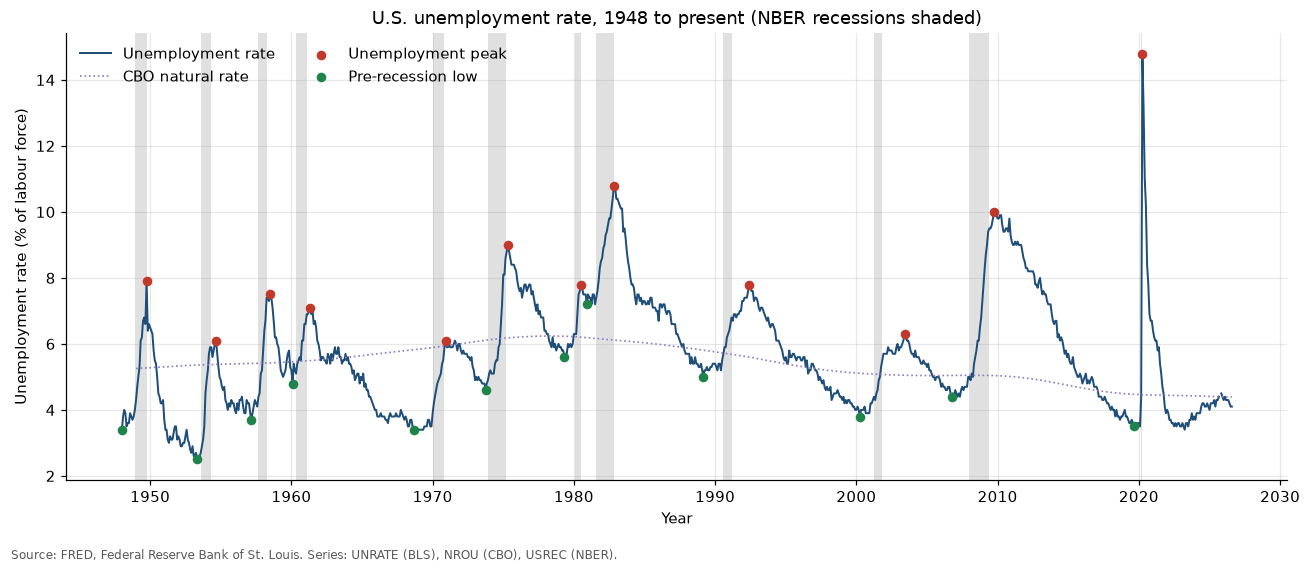

In [ ]:
# Visualization and trends
fig, ax = plt.subplots(figsize=(12, 5))

for start, end in RUNS:
    ax.axvspan(start, end, color="0.80", alpha=0.6, linewidth=0)

ax.plot(df.index, df["UNRATE"], color="#1f4e79", linewidth=1.3, label="Unemployment rate")
ax.plot(df.index, df["NROU"], color="#8e7cc3", linewidth=1.1, linestyle=":", label="CBO natural rate")
ax.scatter(episodes["t_max"], episodes["u_max"], s=28, color="#c0392b", zorder=5, label="Unemployment peak")
ax.scatter(episodes["t_min"], episodes["u_min"], s=28, color="#1e8449", zorder=5, label="Pre-recession low")

ax.set_title("U.S. unemployment rate, 1948 to present (NBER recessions shaded)")
ax.set_xlabel("Year")
ax.set_ylabel("Unemployment rate (% of labour force)")
ax.legend(loc="upper left", frameon=False, ncol=2)
fig.tight_layout()
add_source(fig, "UNRATE", "NROU", "USREC")
fig.savefig(FIGURES_DIR / "fig1_unrate_recessions.png", dpi=150, bbox_inches="tight")
plt.show()

### Figure 2 — Event study: every cycle aligned at its unemployment peak

Each line is one business cycle, shifted so month 0 is that cycle's unemployment peak and
expressed as deviation from the peak. The left half is the run-up into recession; the right
half is the recovery.

**Two panels, because the left one alone would be misleading.** Averaging raw percentage
points across cycles mixes *shape* asymmetry — the claim under test — with *amplitude*
differences between a deep 1982 and a shallow 2001. The right panel divides each cycle by
its own peak-to-trough amplitude, so every line runs from −1 up to 0 and the average curve
shows shape only. If H1 holds, the right panel is steep to the left of zero and shallow to
the right.

2020 is drawn dashed and excluded from both averages.

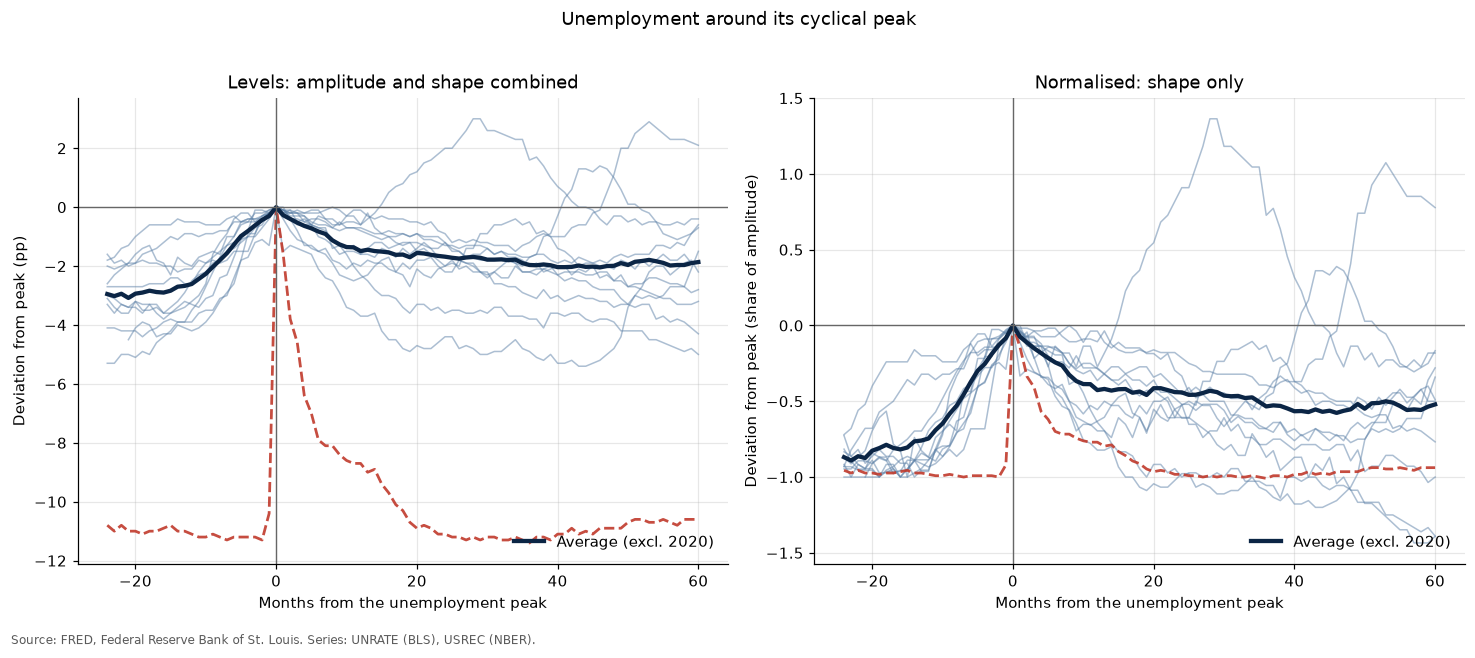

In [ ]:
WIN_PRE, WIN_POST = 24, 60

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.5))
raw_aligned, norm_aligned = {}, {}

for ep in episodes.itertuples():
    window = df["UNRATE"].loc[
        ep.t_max - pd.DateOffset(months=WIN_PRE): ep.t_max + pd.DateOffset(months=WIN_POST)
    ]
    offsets = [months_between(ep.t_max, d) for d in window.index]
    deviation = window.values - ep.u_max
    raw_aligned[ep.label] = pd.Series(deviation, index=offsets)
    norm_aligned[ep.label] = pd.Series(deviation / ep.amplitude, index=offsets)

    is_covid = ep.label == COVID_LABEL
    style = dict(
        linewidth=1.8 if is_covid else 1.0,
        linestyle="--" if is_covid else "-",
        alpha=0.9 if is_covid else 0.5,
        color="#c0392b" if is_covid else "#5a7fa6",
    )
    axes[0].plot(offsets, deviation, **style)
    axes[1].plot(offsets, deviation / ep.amplitude, **style)

panels = [
    (axes[0], raw_aligned, "Levels: amplitude and shape combined", "Deviation from peak (pp)"),
    (axes[1], norm_aligned, "Normalised: shape only", "Deviation from peak (share of amplitude)"),
]
for ax, data, title, ylabel in panels:
    frame = pd.DataFrame(data).sort_index()
    average = frame.drop(columns=[COVID_LABEL], errors="ignore").mean(axis=1)
    ax.plot(average.index, average.values, color="#0b2545", linewidth=2.8, label="Average (excl. 2020)")
    ax.axvline(0, color="0.4", linewidth=0.9)
    ax.axhline(0, color="0.4", linewidth=0.9)
    ax.set_title(title)
    ax.set_xlabel("Months from the unemployment peak")
    ax.set_ylabel(ylabel)
    ax.legend(loc="lower right", frameon=False)

fig.suptitle("Unemployment around its cyclical peak", y=1.02)
fig.tight_layout()
add_source(fig, "UNRATE", "USREC")
fig.savefig(FIGURES_DIR / "fig2_event_study.png", dpi=150, bbox_inches="tight")
plt.show()

### Figure 3 — Speed and duration, cycle by cycle

The paired tests of Section 5.2, drawn. The left panel is speed in pp per month; the right
is the number of months each phase lasted. Both matter: a recovery can be only slightly
slower per month yet take three times as long.

An asterisk marks cycles where unemployment never regained its pre-recession low before the
next recession began, so the green bar understates the true descent duration.

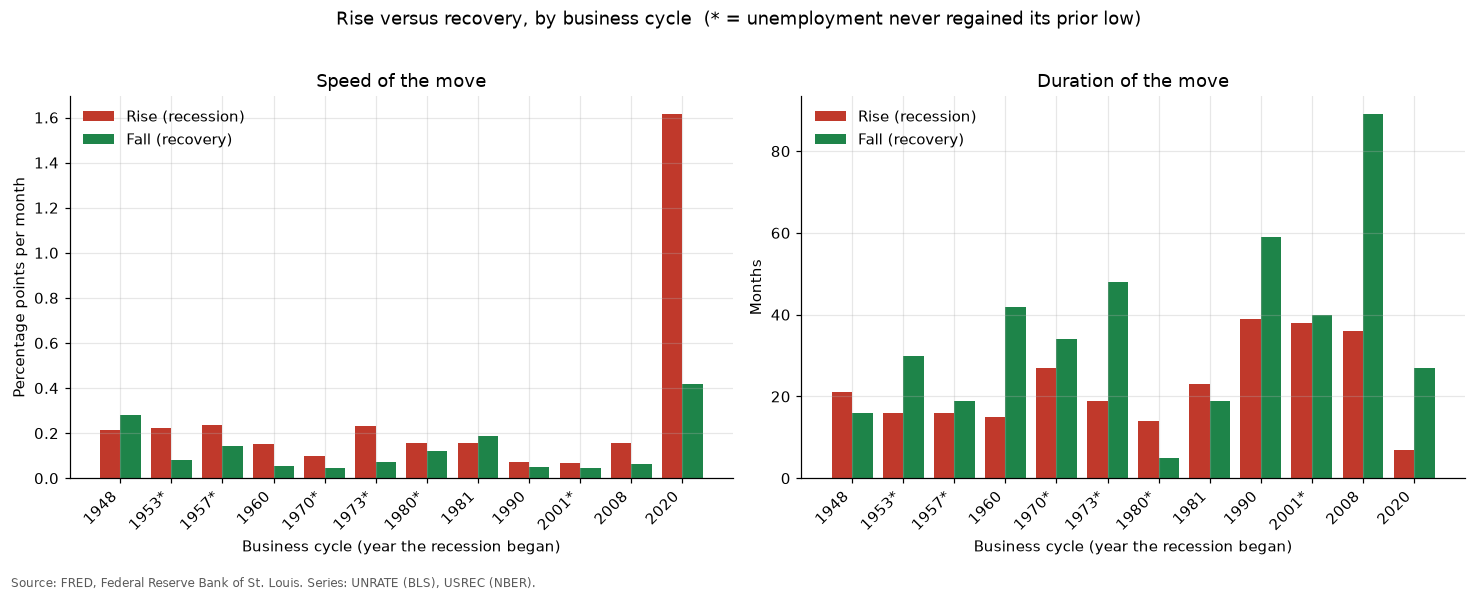

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))

x = np.arange(len(episodes))
width = 0.4
tick_labels = [
    label if recovered else f"{label}*"
    for label, recovered in zip(episodes["label"], episodes["recovered"])
]

axes[0].bar(x - width / 2, episodes["ascent_rate"], width, color="#c0392b", label="Rise (recession)")
axes[0].bar(x + width / 2, episodes["descent_rate"], width, color="#1e8449", label="Fall (recovery)")
axes[0].set_ylabel("Percentage points per month")
axes[0].set_title("Speed of the move")

axes[1].bar(x - width / 2, episodes["months_ascent"], width, color="#c0392b", label="Rise (recession)")
axes[1].bar(x + width / 2, episodes["months_descent"], width, color="#1e8449", label="Fall (recovery)")
axes[1].set_ylabel("Months")
axes[1].set_title("Duration of the move")

for ax in axes:
    ax.set_xlabel("Business cycle (year the recession began)")
    ax.set_xticks(x)
    ax.set_xticklabels(tick_labels, rotation=45, ha="right")
    ax.legend(frameon=False)

fig.suptitle("Rise versus recovery, by business cycle  (* = unemployment never regained its prior low)", y=1.02)
fig.tight_layout()
add_source(fig, "UNRATE", "USREC")
fig.savefig(FIGURES_DIR / "fig3_ascent_vs_descent.png", dpi=150, bbox_inches="tight")
plt.show()

### Figure 4 — Distribution of monthly changes by phase

The pooled test of Section 5.1, drawn. Plotted as **densities, not counts**: recoveries
last far longer than recessions, so on a raw count axis the green bars would tower over the
red ones for a reason that has nothing whatever to do with the hypothesis. `density=True`
makes the two distributions comparable in shape.

The x-axis is clipped to ±0.6 pp so the mass near zero stays readable; the 2020
observations lie far outside that range, which is the point of the robustness check.

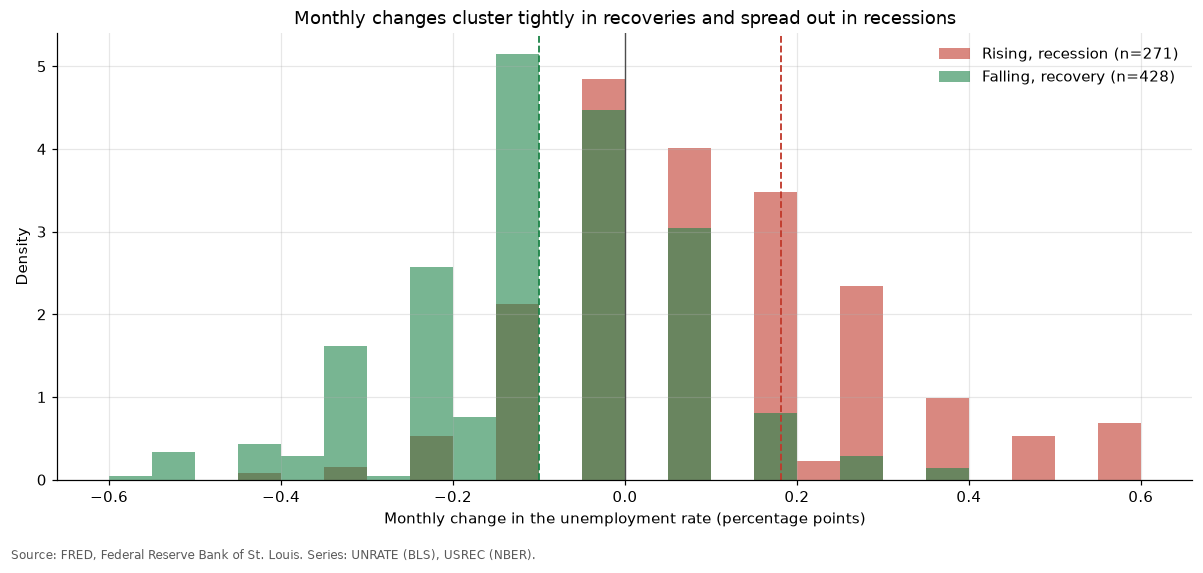

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))

bins = np.arange(-0.6, 0.65, 0.05)
ascent_changes = phased.loc[phased["phase"] == "ascent", "d_unrate"]
descent_changes = phased.loc[phased["phase"] == "descent", "d_unrate"]

ax.hist(ascent_changes, bins=bins, density=True, alpha=0.6, color="#c0392b",
        label=f"Rising, recession (n={len(ascent_changes)})")
ax.hist(descent_changes, bins=bins, density=True, alpha=0.6, color="#1e8449",
        label=f"Falling, recovery (n={len(descent_changes)})")

ax.axvline(0, color="0.3", linewidth=0.9)
ax.axvline(ascent_changes.mean(), color="#c0392b", linestyle="--", linewidth=1.2)
ax.axvline(descent_changes.mean(), color="#1e8449", linestyle="--", linewidth=1.2)
ax.set_xlabel("Monthly change in the unemployment rate (percentage points)")
ax.set_ylabel("Density")
ax.set_title("Monthly changes cluster tightly in recoveries and spread out in recessions")
ax.legend(frameon=False)
fig.tight_layout()
add_source(fig, "UNRATE", "USREC")
fig.savefig(FIGURES_DIR / "fig4_change_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 8. Conclusion

The cell below collects every test into one table, writes it to
`results/tables/results_summary.csv`, and states the verdict **separately for speed and
for duration**, because the two claims are not equally well supported.

**On multiple testing.** A dozen or so tests of a single hypothesis are reported. They are
far from independent — most reuse the same months — so a Bonferroni correction is
conservative rather than correct. The threshold is printed anyway, and each verdict
requires **all** of its primary tests to reject, not the most favourable one. Reporting
only the tests that rejected would be the real error.

In [ ]:
results = pd.DataFrame([
    {"test": "Welch t, pooled monthly changes", "family": "speed (primary)",
     "statistic": t_stat, "p_value": t_p, "n": len(rise_speed) + len(fall_speed)},
    {"test": "Mann-Whitney U, pooled monthly changes", "family": "speed (primary)",
     "statistic": u_stat, "p_value": u_p, "n": len(rise_speed) + len(fall_speed)},
    {"test": "Paired t, speed per cycle", "family": "speed (primary)",
     "statistic": t_stat_p, "p_value": t_p_p, "n": len(paired)},
    {"test": "Wilcoxon, speed per cycle", "family": "speed (primary)",
     "statistic": w_stat, "p_value": w_p, "n": len(paired)},
    {"test": "Paired t, duration per cycle", "family": "duration (primary)",
     "statistic": t_dur, "p_value": p_dur, "n": len(paired)},
    {"test": "Wilcoxon, duration per cycle", "family": "duration (primary)",
     "statistic": w_dur, "p_value": wp_dur, "n": len(paired)},
    {"test": "Paired t, completed recoveries only", "family": "sensitivity",
     "statistic": t_comp, "p_value": p_comp, "n": len(complete)},
    {"test": "Paired t, genuine pre-recession low only", "family": "sensitivity",
     "statistic": t_low, "p_value": p_low, "n": len(genuine_low)},
    {"test": "Paired t, episodes redated on the u-gap", "family": "sensitivity",
     "statistic": t_gap, "p_value": p_gap, "n": len(paired_gap)},
    {"test": "Skewness, excluding 2020-21", "family": "supporting",
     "statistic": skew_results["Excluding 2020-21"][0],
     "p_value": skew_results["Excluding 2020-21"][2], "n": skew_results["Excluding 2020-21"][3]},
    {"test": "Regression beta, NBER dummy (HAC)", "family": "regression",
     "statistic": model_nber.params["recession"], "p_value": model_nber.pvalues["recession"],
     "n": int(model_nber.nobs)},
    {"test": "Regression beta, rising phase (HAC)", "family": "regression",
     "statistic": model_phase.params["rising"], "p_value": model_phase.pvalues["rising"],
     "n": int(model_phase.nobs)},
    {"test": "Regression beta, excluding 2020-21 (HAC)", "family": "regression",
     "statistic": model_ex_covid.params["rising"], "p_value": model_ex_covid.pvalues["rising"],
     "n": int(model_ex_covid.nobs)},
    {"test": "Regression beta, rising phase (clustered)", "family": "regression",
     "statistic": model_cluster.params["rising"], "p_value": model_cluster.pvalues["rising"],
     "n": int(model_cluster.nobs)},
]).set_index("test")

results.to_csv(TABLES_DIR / "results_summary.csv")
results["p_reported"] = results["p_value"].map(fmt_p)
print(fmt_table(results[["family", "statistic", "p_reported", "n"]]))

speed_tests = {"Welch": t_p, "Mann-Whitney": u_p, "Paired t": t_p_p, "Wilcoxon": w_p}
duration_tests = {"Paired t": p_dur, "Wilcoxon": wp_dur}
worst_speed = max(speed_tests.values())
worst_duration = max(duration_tests.values())
rise_mean, fall_mean = rise_speed.mean(), fall_speed.mean()

print("\n" + "=" * 80)
print("Does unemployment rise faster than it falls?")
print("=" * 80)
print(f"Sample                 : {df.index.min():%Y-%m} to {df.index.max():%Y-%m}, "
      f"{len(df)} months, {len(episodes)} business cycles")
print(f"Speed while rising     : {rise_mean:.4f} pp/month")
print(f"Speed while falling    : {fall_mean:.4f} pp/month")
print(f"Rise is                : {rise_mean / fall_mean:.2f}x faster than the fall")
print(f"Median rise duration   : {paired['months_ascent'].median():.0f} months")
print(f"Median fall duration   : {paired['months_descent'].median():.0f} months")
print(f"Cycles, rise faster    : {(paired['ascent_rate'] > paired['descent_rate']).sum()} of {len(paired)}")
print(f"Cycles, fall longer    : {(paired['months_descent'] > paired['months_ascent']).sum()} of {len(paired)}")
print(f"\nBonferroni threshold for {len(results)} tests: {0.05 / len(results):.4g} "
      f"(conservative; tests are not independent)")
print("-" * 80)
print(f"SPEED    largest p among {len(speed_tests)} primary tests: "
      f"{fmt_p(worst_speed)}  ({max(speed_tests, key=speed_tests.get)})")
print("         verdict: " + ("H0 REJECTED by all primary tests" if worst_speed < 0.05
                              else "H0 NOT rejected by all primary tests"))
print(f"DURATION largest p among {len(duration_tests)} primary tests: "
      f"{fmt_p(worst_duration)}  ({max(duration_tests, key=duration_tests.get)})")
print("         verdict: " + ("H0 REJECTED by all primary tests" if worst_duration < 0.05
                              else "H0 NOT rejected by all primary tests"))
print("=" * 80)

                                                       family  statistic p_reported    n
test                                                                                    
Welch t, pooled monthly changes               speed (primary)      1.966    0.02511  699
Mann-Whitney U, pooled monthly changes        speed (primary)  6.575e+04   0.001316  699
Paired t, speed per cycle                     speed (primary)      1.568    0.07262   12
Wilcoxon, speed per cycle                     speed (primary)         69   0.008057   12
Paired t, duration per cycle               duration (primary)      2.539    0.01376   12
Wilcoxon, duration per cycle               duration (primary)         65    0.02051   12
Paired t, completed recoveries only               sensitivity      1.106     0.1595    6
Paired t, genuine pre-recession low only          sensitivity      1.654    0.06458   11
Paired t, episodes redated on the u-gap           sensitivity      1.777      0.053   11
Skewness, excluding 2

### 8.1 Interpretation

**In short.** Yes: U.S. unemployment rises faster than it falls. Across 12 postwar
business cycles the rise lasts a median of 20 months and the recovery 32, and while rising
unemployment moves about 1.8 times as fast per month as it does while falling. The duration
result passes every primary test at 5%. The speed result is clear in the point estimates
and in the rank tests, but the single most conservative test, the paired t-test, misses
5% (p ≈ 0.07). The main limitation is sample size: twelve cycles, one of them (2020) an
extreme outlier.

Every figure quoted below comes from the run shown above; the data vintage is recorded in
`data/raw/_manifest.csv`.

**The answer depends on which meaning of "faster" is asked about, and that split is the
main finding of the study.**

**Duration: yes.** Recoveries take longer than the rises that precede them. The median
unemployment ascent runs 20 months and the median descent 32, a median gap of about 10
months. The fall took longer than the rise in 9 of 12 cycles, and both the paired t-test
(p ≈ 0.014) and Wilcoxon (p ≈ 0.021) reject at 5%. Neither clears the Bonferroni
threshold of 0.0036, but that threshold assumes 14 independent tests and these reuse the
same months, so it is far stricter than the true family-wise rate. The duration gap is also
*understated*: in 6 of the 12 cycles the next downturn arrived before unemployment regained
its prior low, which cut those recoveries short.

**Speed: probably, but the evidence is weaker than the headline ratio suggests.** The point
estimate is clear: unemployment rises at about 0.18 pp per month and falls at about 0.10,
a ratio near 1.8x (median 2.0x across cycles), with the rise faster in 10 of 12 cycles. But
the four primary tests do not agree. The two rank-based tests reject firmly (Mann–Whitney
p ≈ 0.001, Wilcoxon p ≈ 0.008). Of the two mean-based tests, the pooled Welch test rejects
(p ≈ 0.025) and the paired t-test does not (p ≈ 0.073). That pattern is diagnostic rather
than contradictory: the t-tests are dragged down by the enormous variance the 2020 episode
injects, and rank tests are immune to it. Excluding 2020–21, the pooled comparison
strengthens sharply (p ≈ 3e-05). **The honest statement is that the speed asymmetry is
clearly present in the data but is not established beyond doubt by the single most
conservative test available.**

**Three findings that complicate the story, and belong in the write-up rather than buried:**

1. **In the pooled data the speed asymmetry is significant only pre-1985.** Before 1985 the
   gap is strongly significant (p ≈ 0.0006); after 1985 it is not (p ≈ 0.17), despite an
   almost identical point ratio of 1.8x. The later sample simply contains fewer and longer
   cycles, so power collapses. That is consistent with the "jobless recoveries" literature,
   but the identical ratios mean it should not be read as a structural break.
2. **Restricting to completed recoveries weakens the speed result** (n = 6, p ≈ 0.16).
   With only six pairs the test has almost no power, so this is inconclusive rather than a
   refutation, but it must be reported.
3. **Persistence is essentially zero at monthly frequency** (γ ≈ −0.01, p ≈ 0.73), so the
   cumulative effect β/(1−γ) is indistinguishable from the impact effect β. The asymmetry
   is a level difference between regimes, not a propagation mechanism: once the regime is
   controlled for, the monthly change does not feed on itself.

**What survives everything.** The regression beta is large and precisely estimated
under every error structure and sample (beta ≈ +0.28 pp/month on the full sample, +0.23
excluding COVID, p < 1e-4 under HAC and clustered errors alike). The normalised event study
in Figure 2 shows the sawtooth shape directly. And the skewness test excluding COVID
confirms right skew without using recession dates at all (+0.35, p ≈ 2e-05).

Three sensitivity checks are worth quoting. **Detrended payroll growth** reproduces the
asymmetry on a completely different variable (2.02x, p ≈ 0.010): employment falls further
below trend in downturns than it rises above trend in recoveries, so the result is not an
artifact of how the unemployment rate is defined and is not explained by discouraged
workers leaving the labour force. **Dropping the 1948 episode**, whose pre-recession low is
censored by the start of the data, moves the paired speed test from p ≈ 0.073 to
p ≈ 0.065, so that episode is not driving the result either way. **Rebuilding every
episode on the unemployment gap** (unemployment minus CBO's natural rate) gives p ≈ 0.053,
in line with the baseline.

**Economic implication.** Labour-market damage is not undone on a symmetric timetable. The
cost of a downturn is front-loaded and the repair is slow: roughly 20 months of
deterioration against 32 months of healing. That is an argument for stabilisation policy
acting early. Delay is not cost-neutral, because months spent waiting are added to the long
side of the cycle, not the short one.

### 8.2 Caveats

- **Low power, and it bites here.** Twelve cycles is not many. The paired speed test lands
  at p ≈ 0.073 with a 2.0x median effect. That is a power problem, not evidence of
  symmetry.
- **COVID dominates the moments.** April 2020 is a +10.4 pp observation in a series whose
  typical move is 0.1 pp. Full-sample skewness of +16.7 and residual kurtosis of 377 are
  statements about that one month. Every conclusion is therefore checked with 2020–21
  excluded, and the excluded versions are the ones to quote.
- **Unfinished recoveries.** Six of twelve episodes never saw unemployment regain its prior
  low before the next recession. Their descent is measured to the lowest rate reached,
  which understates how long a full recovery would have taken. That biases the duration
  test *against* H1; Section 5.2 reruns the speed test without these episodes.
- **The 1948 episode's ascent starts at the first month of the data**, not a genuine
  cyclical trough (flagged `t_min_censored`). Section 5.2 reruns without it.
- **Labour-force participation.** The unemployment rate falls when people find work *and*
  when they give up looking. The detrended payroll row in 5.4 is the check. The *raw*
  payroll row is reported beside it only to show why detrending is required: payrolls grow
  with the labour force while the unemployment rate does not, so the raw comparison credits
  recoveries with secular growth and is not a valid test.
- **The natural rate is not constant.** Section 5.4 addresses this twice: once by
  redefining the monthly change as the change in the gap, and once by rebuilding every
  episode on the gap. CBO's `NROU` is itself a model estimate, not data, and is
  interpolated from quarterly to monthly here.
- **Dating is a judgment call.** NBER dates are announced with a long lag and are partly
  discretionary. The analysis avoids depending on them; 5.4 reports the NBER-dated version.
- **Missing data.** FRED has no `UNRATE` observation for October 2025, during the federal
  government shutdown. It is kept as a gap, so no monthly change spans it.
- **Data vintage.** `UNRATE` is revised. Results correspond to the vintage recorded in
  `data/raw/_manifest.csv`.
- **Descriptive, not causal.** This documents an asymmetry. It does not identify its cause:
  hiring frictions, search behaviour, firing costs and hysteresis are all candidates, and
  they are not distinguished here.

### Data sources

U.S. Bureau of Labor Statistics (`UNRATE`, `PAYEMS`), National Bureau of Economic Research
(`USREC`), and Congressional Budget Office (`NROU`), retrieved from FRED, Federal Reserve
Bank of St. Louis, https://fred.stlouisfed.org. Vintage as recorded in
`data/raw/_manifest.csv`.